# Planning a telescope observation

The objective is to build a weather forecast to plan an expensive observational campaign, by knowing that the weather tomorrow depends on the one today as:
* p(clear tomorrow|cloudy today) = 0.5 and p(cloudy tomorrow|cloudy today) = 0.5 ;
* p(clear tomorrow|clear today) = 0.9 and p(cloudy tomorrow|clear today) = 0.1 .

The prediction algorithm will be built through a Markov Chain as follows. Starting from the current day the prediction on tomorrow will be ruled by the drawn of a number from a uniform distribution between 0 and 1 U[0,1]. This number is then compared in magnitude to the corresponding probability, depending on the weather today: to be explicit, if today is a clear day and the number I extracted is smaller than 0.1, then tomorrow will be identified as cloudy (indeed I have 10% of probability to draw a number smaller than 0.1 from U[0,1]).

After enough days, if the chain is stationary and well defined, the equilibrium probabilities should be reached: p(clear) = 0.83 and p(cloudy) = 0.17

### Tasks

* Start off on a cloudy day;
* Implement your weather forecast based on the above probabilities
* Run your simulator for N days (with $N>10^4$);
* Prepare a plot with the number of days on the x axis and the cumulative fraction of, say, sunny days over the number of days so far on the y axis. This is called a trace-plot, showing how our estimate of p(clear) evolves as the chain samples.
* Prepare a histogram of the above plot. This reveals the distribution of p(clear).
* Use a summary statistics to determine the most likely value and an error on our estimate.

In [8]:
import numpy as np

In [9]:
# 0 cloudy
# 1 clear

N =10**4

def sunnycloudy_MC(N, init=0):
    chain = [init]
    for i in range(N):
        next_prob =  np.random.uniform(0,1,1)
        next_day = 0
        if init == 0: #today is cloudy
            if next_prob <0.5:
                chain.append(0)
                next_day = 0
            else:
                chain.append(1)
                next_day = 1
                
        else:        #today is clear
            if next_prob<0.1:
                chain.append(0)
                next_day = 0
            else:
                chain.append(1)
                next_day = 1
        init = next_day #next step
    return chain
        
        
        

In [22]:
days = sunnycloudy_MC(N, init=0)

Text(0.5, 1.0, 'Traceplot')

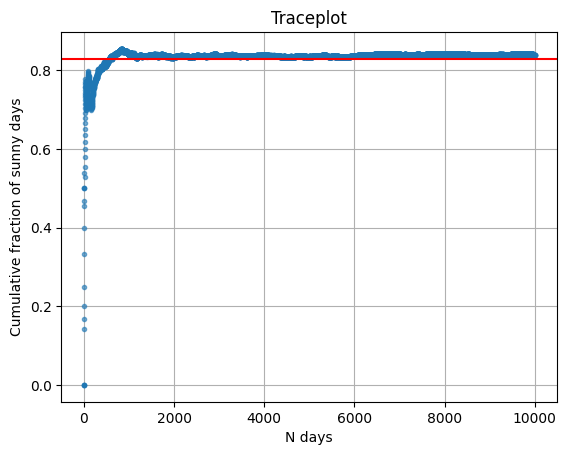

In [23]:
import matplotlib.pyplot as plt

x = np.arange(N)
cum = [np.sum(days[:i])/(i+1) for i in range(N)]
plt.plot(x, cum, '.', alpha=0.6)
plt.axhline(0.83, color='red')
plt.xlabel('N days')
plt.ylabel('Cumulative fraction of sunny days')
plt.grid()
plt.title('Traceplot')

In [12]:
def scott_rule_histo(data):
    bin_width = 3.5*np.std(data)/len(data)**(1/3)
    bins = np.append(np.arange(start=data.min(), stop=data.max(), step=bin_width) , data.max())  # Create edges
   # print(f"Scott's bin width: {bin_width}")
    return bins


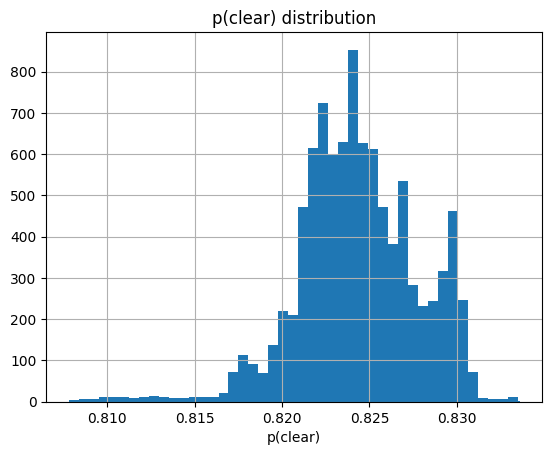

In [13]:
#reject the burn in phase of the traceplot

plt.hist(cum[500:], bins= scott_rule_histo(np.array(cum[500:])))#, density='True')
plt.grid()
plt.xlabel('p(clear)')
plt.title('p(clear) distribution')
plt.show()

In [14]:
np.mean(cum[500:])

np.float64(0.8243490594811699)

In [15]:
np.std(cum[500:])/len(cum[500:])

np.float64(3.639693124624965e-07)

Text(0.5, 1.0, 'Traceplot')

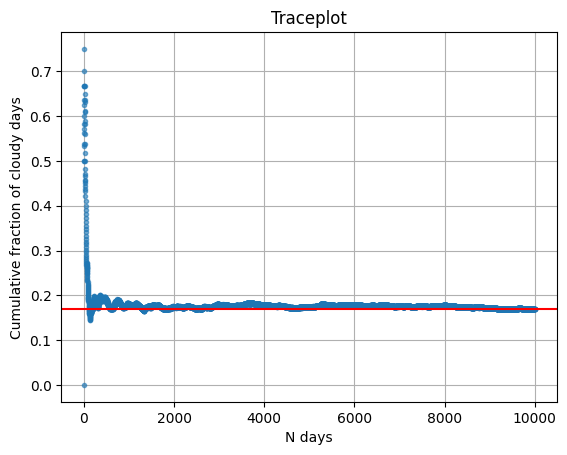

In [16]:
x = np.arange(N)
days_aus = np.array(days)
index_0 = np.where(np.array(days)==0)[0]
index_1 = np.where(np.array(days)==1)[0]
days_aus[index_0]= 1
days_aus[index_1] = 0
cum = [np.sum(days_aus[:i])/(i+1) for i in range(N)]
plt.plot(x, cum, '.', alpha=0.6)
plt.axhline(0.17, color='red')
plt.xlabel('N days')
plt.ylabel('Cumulative fraction of cloudy days')
plt.grid()
plt.title('Traceplot')

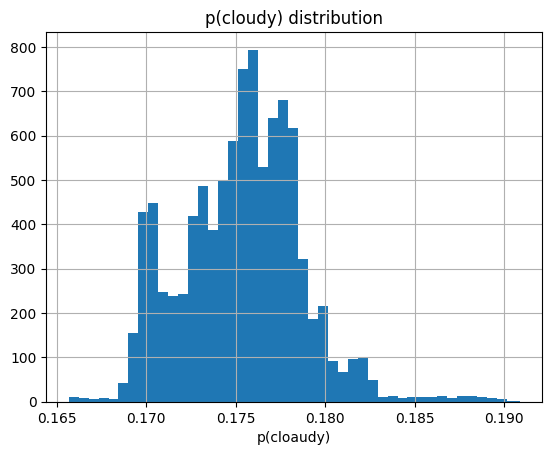

In [17]:
#reject the burn in phase of the traceplot

plt.hist(cum[500:], bins= scott_rule_histo(np.array(cum[500:])))#, density='True')
plt.grid()
plt.xlabel('p(cloaudy)')
plt.title('p(cloudy) distribution')
plt.show()

In [18]:
np.mean(cum[500:])

np.float64(0.17533570024450862)

In [19]:
np.std(cum[500:])/len(cum[500:])

np.float64(3.5472546494435577e-07)

# Stock market

In [24]:
# 1 recession
# 2 bear
# 3 bull

N =10**6

def stock_MC(N, init=1):
    chain = [init]
    for i in range(N):
        next_prob =  np.random.uniform(0,1,1)
        next_day = 1
        if init == 1: 
            if next_prob <0.5:
                chain.append(1)
                next_day = 1
            elif next_prob>0.75:
                chain.append(2)
                next_day = 2
            else:
                chain.append(3)
                next_day = 3
                
        elif init==2:        #today is clear
            if next_prob<0.8:
                chain.append(2)
                next_day = 2
            elif next_prob>0.95:
                chain.append(1)
                next_day = 1
            else:
                chain.append(3)
                next_day = 3
        else:
            if next_prob<0.9:
                chain.append(3)
                next_day = 3
            elif next_prob>0.925:
                chain.append(2)
                next_day = 2
            else:
                chain.append(1)
                next_day=1
                
        init = next_day #next step
    return chain
        
        
        

In [25]:
market = stock_MC(N)

In [ ]:
x = np.arange(N)
market_aus = np.array(market)
mask_2 = np.where(market_aus ==2)
mask_3 = np.where(market_aus ==3)
market_aus[mask_2]=0
market_aus[mask_3]=0
cum = [np.sum(market_aus[:i])/(i+1) for i in range(N)]
plt.plot(x, cum, '.', alpha=0.6)
plt.xlabel('N days')
plt.ylabel('Cumulative fraction of recessional days')
plt.grid()
plt.title('Traceplot')

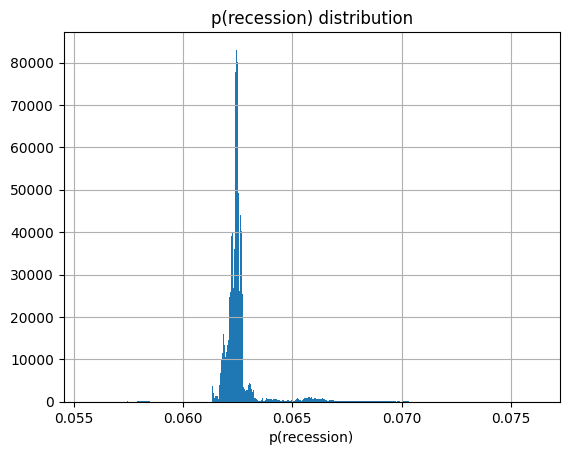

In [27]:
#reject the burn in phase of the traceplot

plt.hist(cum[500:], bins= scott_rule_histo(np.array(cum[500:])))#, density='True')
plt.grid()
plt.xlabel('p(recession)')
plt.title('p(recession) distribution')
plt.show()

Text(0.5, 1.0, 'Traceplot')

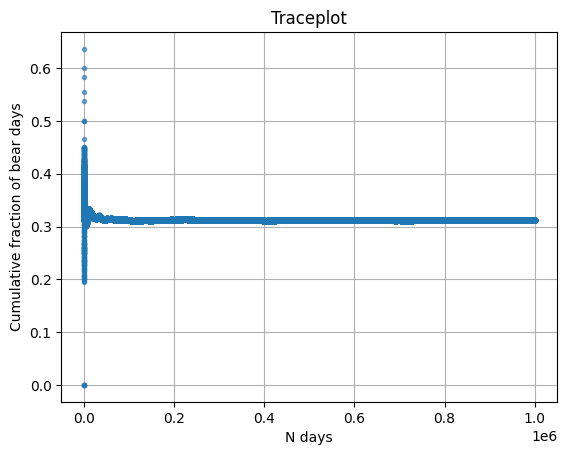

In [28]:
x = np.arange(N)
market_aus = np.array(market)
mask_2 = np.where(market_aus ==1)
mask_3 = np.where(market_aus ==3)
market_aus[mask_2]=0
market_aus[mask_3]=0
cum = [0.5*np.sum(market_aus[:i])/(i+1) for i in range(N)]
plt.plot(x, cum, '.', alpha=0.6)
plt.xlabel('N days')
plt.ylabel('Cumulative fraction of bear days')
plt.grid()
plt.title('Traceplot')

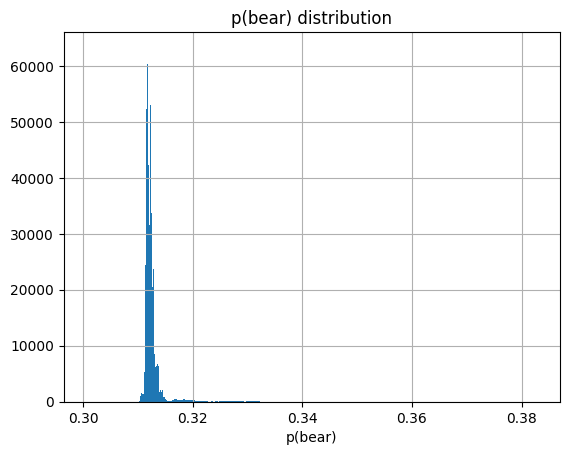

In [29]:
#reject the burn in phase of the traceplot

plt.hist(cum[500:], bins= scott_rule_histo(np.array(cum[500:])))#, density='True')
plt.grid()
plt.xlabel('p(bear)')
plt.title('p(bear) distribution')
plt.show()

Text(0.5, 1.0, 'Traceplot')

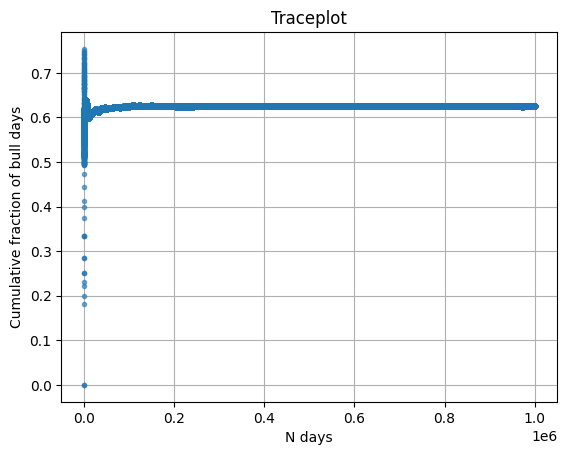

In [30]:
x = np.arange(N)
market_aus = np.array(market)
mask_2 = np.where(market_aus ==2)
mask_3 = np.where(market_aus ==1)
market_aus[mask_2]=0
market_aus[mask_3]=0
cum = [np.sum(market_aus[:i])/(i+1) *(1/3) for i in range(N)]
plt.plot(x, cum, '.', alpha=0.6)
plt.xlabel('N days')
plt.ylabel('Cumulative fraction of bull days')
plt.grid()
plt.title('Traceplot')

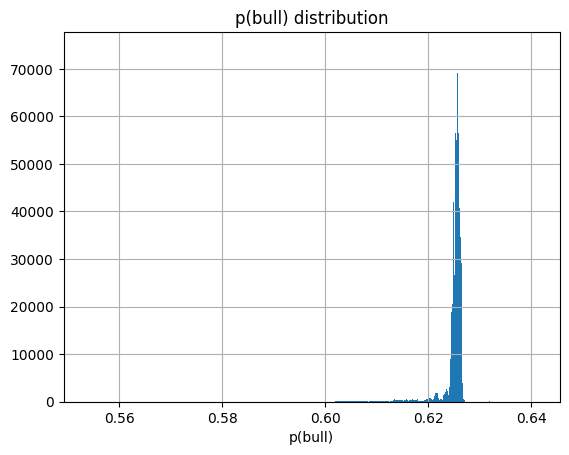

In [31]:
#reject the burn in phase of the traceplot

plt.hist(cum[500:], bins= scott_rule_histo(np.array(cum[500:])))#, density='True')
plt.grid()
plt.xlabel('p(bull)')
plt.title('p(bull) distribution')
plt.show()

## Math problem
Generalize the code for $\pi$ calcultaion to compute the volume of an N-dimensional sphere as a function of the number of dimension N. Warning: the $N \rightarrow \inf$ limit is very surprising.

In [1]:
# Execute this cell
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt

d= 1   MC=2.000000e+00   exact=2.000000e+00   rel_error=0.00e+00
d= 2   MC=3.144080e+00   exact=3.141593e+00   rel_error=7.92e-04
d= 3   MC=4.179040e+00   exact=4.188790e+00   rel_error=-2.33e-03
d= 4   MC=4.932720e+00   exact=4.934802e+00   rel_error=-4.22e-04
d= 5   MC=5.311200e+00   exact=5.263789e+00   rel_error=9.01e-03
d=10   MC=2.360320e+00   exact=2.550164e+00   rel_error=-7.44e-02
d=20   MC=0.000000e+00   exact=2.580689e-02   rel_error=-1.00e+00
d=50   MC=0.000000e+00   exact=1.730219e-13   rel_error=-1.00e+00


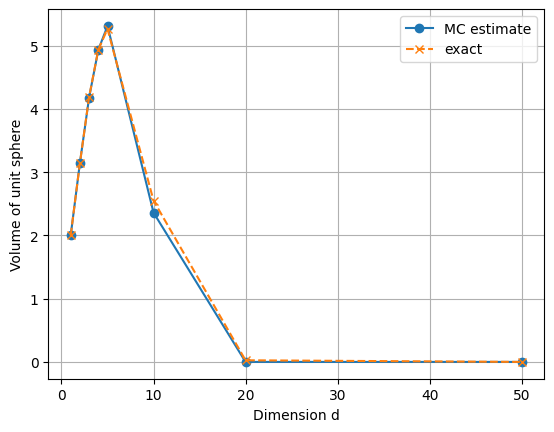

In [7]:
def estimate_sphere_volume(d, M=200000):
    points = np.random.uniform(-1, 1, size=(M, d))
    inside = np.sum(np.sum(points**2, axis=1) <= 1)
    return (2**d) * inside / M
import scipy.special
def exact_sphere_volume(d):
    return np.pi**(d / 2) / scipy.special.gamma(d / 2 + 1)

dims = [1, 2, 3, 4, 5, 10, 20, 50]
estimates = [estimate_sphere_volume(d, M=200000) for d in dims]
exacts = [exact_sphere_volume(d) for d in dims]

for d, est, ex in zip(dims, estimates, exacts):
    print(f"d={d:2d}   MC={est:.6e}   exact={ex:.6e}   rel_error={(est-ex)/ex:.2e}")

plt.figure()
plt.plot(dims, estimates, 'o-', label='MC estimate')
plt.plot(dims, exacts, 'x--', label='exact')
#plt.yscale('log')
plt.xlabel('Dimension d')
plt.ylabel('Volume of unit sphere')
plt.legend()
plt.grid()